# Reparameterized Variational Inference (NumPyro)

## Real-World Scenario: Inferring mRNA Kinetic Parameters from RNA-seq Counts

**From PML-2 Chapter 10.2**

This is a NumPyro port of `10-2-1-reparameterized_vi.ipynb`. Same scenario, same math, same plots — but the generative model is declared with `numpyro.sample`, the three Gaussian variational families come from `numpyro.infer.autoguide`, and training is driven by `numpyro.infer.SVI` with `Trace_ELBO`.

In whole-cell modeling, every gene has two kinetic parameters that govern its mRNA pool:
- $k_{\text{syn}}$ — transcription rate (mRNAs produced per unit time)
- $k_{\text{deg}}$ — degradation rate (fraction of pool degraded per unit time)

At steady state, the mean mRNA copy number is the ratio $\lambda = k_{\text{syn}} / k_{\text{deg}}$.

RNA-seq gives us **noisy count observations** of that steady-state pool, modeled as Poisson. The catch: the data only constrains the **ratio**, not the individual rates. That makes the joint posterior $p(\log k_{\text{syn}}, \log k_{\text{deg}} \mid \text{data})$ highly correlated along the diagonal — a classic banana-shape that exposes the weakness of mean-field variational inference.

We use this as a testbed to compare three Gaussian variational families described in Section 10.2.1:

1. **Diagonal covariance** (mean field) — `AutoNormal`, Section 10.2.1.1
2. **Full covariance** via Cholesky — `AutoMultivariateNormal`, Section 10.2.1.2
3. **Low-rank + diagonal** (factor) covariance — `AutoLowRankMultivariateNormal`, Section 10.2.1.3

All three are trained via the **reparameterization trick**: gradients flow through stochastic samples by writing $z = g(\boldsymbol{\phi}, \boldsymbol{\epsilon})$ with $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$. NumPyro applies the trick automatically for any `has_rsample` distribution — we never write $\log q$ or $\log p$ by hand.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp
import jax.random as jr

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import (
    AutoNormal,
    AutoMultivariateNormal,
    AutoLowRankMultivariateNormal,
)

key = jr.PRNGKey(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formulas from PML-2 Chapter 10.2

### The ELBO (Eq. 10.9 / 10.11)
$$\mathcal{L}_{\text{ELBO}}(\boldsymbol{\psi}) \;=\; \mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}\!\left[\log p(\mathbf{x}, \mathbf{z}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})\right] \;\le\; \log p(\mathbf{x})$$

`Trace_ELBO` evaluates exactly this Monte Carlo estimator: it traces the model to get $\log p(\mathbf{x}, \mathbf{z})$, traces the guide to get $\log q_{\boldsymbol{\psi}}(\mathbf{z})$, and averages the difference over `num_particles` samples.

### Reparameterization (Eq. 10.36 / 10.40)
Rewrite $\mathbf{z} \sim q_{\boldsymbol{\psi}}(\mathbf{z})$ as $\mathbf{z} = g(\boldsymbol{\psi}, \boldsymbol{\epsilon})$ with $\boldsymbol{\epsilon} \sim p(\boldsymbol{\epsilon})$ free of $\boldsymbol{\psi}$:
$$\nabla_{\boldsymbol{\psi}}\,\mathbb{E}_{q_{\boldsymbol{\psi}}(\mathbf{z})}[f(\mathbf{z})] \;=\; \mathbb{E}_{p(\boldsymbol{\epsilon})}\!\left[\nabla_{\boldsymbol{\psi}}\, f\!\left(g(\boldsymbol{\psi}, \boldsymbol{\epsilon})\right)\right]$$

NumPyro distributions like `Normal`, `MultivariateNormal`, and `LowRankMultivariateNormal` expose `has_rsample = True`. SVI uses `rsample` automatically when computing the gradient, so reparameterization is fully implicit.

### Three Gaussian families (and the NumPyro autoguide that maps to each)
| Family | Reparameterization | Parameters | NumPyro guide |
|---|---|---|---|
| Diagonal (Eq. 10.44) | $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$ | $2d$ | `AutoNormal` |
| Full (Eq. 10.52) | $\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}$, $\boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top$ | $d + d(d{+}1)/2$ | `AutoMultivariateNormal` |
| Low-rank + diag (Eq. 10.57) | $\boldsymbol{\Sigma} = \mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2)$ | $(r{+}2)d$ | `AutoLowRankMultivariateNormal` |

### What NumPyro does for us
- **Model declaration** with `numpyro.sample` *is* the joint $\log p(\mathbf{x}, \mathbf{z})$ — no hand-derived log-likelihood.
- **Autoguides** stand in for the hand-written `sample(params, key, S) -> (z, log_q)` functions of the JAX notebook. Each autoguide bundles `(params, sampling rule, log-density rule)` inside one class.
- **`SVI` + `Trace_ELBO`** runs the reparameterized gradient step. `svi.update` is internally JIT-compiled; the Python loop is just there so we can log progress.

## Step 1: The Generative Model

The generative model is a small story for how the observed RNA counts could have been produced. For one gene, imagine an unobserved mRNA birth-death process:
- mRNAs are synthesized at rate $k_{\text{syn}}$
- each existing mRNA molecule degrades independently at rate $k_{\text{deg}}$
- at steady state, the expected mRNA copy number is
  $$\lambda = \frac{k_{\text{syn}}}{k_{\text{deg}}}$$

We parameterize on the log-scale so the rates stay positive:
- $\theta_1 = \log k_{\text{syn}}$, $\theta_2 = \log k_{\text{deg}}$
- Prior: $\theta_1, \theta_2 \sim \mathcal{N}(0, 1)$ (weakly informative)
- Steady-state mean: $\lambda = \exp(\theta_1 - \theta_2)$
- Likelihood (RNA-seq replicates): $y_n \sim \mathrm{Poisson}\!\left(\lambda\right)$, for $n = 1, \dots, N$

Why Poisson? The observations are **counts**, so they must be nonnegative integers. The Poisson distribution is the simplest model for independent count events around an average rate $\lambda$. It also matches the simple birth-death intuition: when mRNAs are produced at a constant rate and degraded independently, the steady-state copy number is Poisson with mean $k_{\text{syn}}/k_{\text{deg}}$.

So the model is
$$\theta_1, \theta_2 \sim \mathcal{N}(0, 1), \qquad \lambda = e^{\theta_1 - \theta_2}, \qquad y_n \sim \mathrm{Poisson}(\lambda).$$

Because the likelihood depends only on $\theta_1 - \theta_2$, the data constrains the **ratio** $k_{\text{syn}}/k_{\text{deg}}$, not the two rates separately. If both rates move together, the ratio can stay almost unchanged. That is why the posterior forms a narrow diagonal band shrunk toward the origin by the prior.

### From hand-written log-density to a NumPyro model

The JAX-only sibling notebook spends two cells deriving the joint $\log p(\boldsymbol{\theta}, \mathbf{y})$ explicitly, because the SVI trainer needs to evaluate it at every gradient step. NumPyro removes that step: the joint is **implicit in the model declaration**. When `Trace_ELBO` runs the model under a sample trace, every `numpyro.sample` site contributes its `log_prob` to the running joint, and observed sites do likewise. The same expression
$$\log p(\boldsymbol{\theta}, \mathbf{y}) = -\tfrac{1}{2}(\theta_1^2 + \theta_2^2) + \Big(\sum_n y_n\Big)(\theta_1 - \theta_2) - N e^{\theta_1 - \theta_2} + \text{const}$$
is what NumPyro reconstructs internally from the four lines of `def model(...)` below. We get it for free in exchange for declaring the priors and likelihood as sample sites.

In [2]:
# --- Ground-truth kinetic parameters for one gene ---
k_syn_true = 8.0    # mRNAs per unit time
k_deg_true = 2.0    # fraction per unit time -> steady-state lambda = 4 copies
lambda_true = k_syn_true / k_deg_true

theta_true = np.array([np.log(k_syn_true), np.log(k_deg_true)])
print(f"True (log k_syn, log k_deg) = ({theta_true[0]:.3f}, {theta_true[1]:.3f})")
print(f"Steady-state lambda = {lambda_true:.2f} mRNA copies")

# --- Simulate RNA-seq replicate counts ---
N = 30  # number of replicate count measurements
y_obs = np.random.poisson(lam=lambda_true, size=N)
print(f"\nObserved counts (first 10 of {N}): {y_obs[:10]}")
print(f"Sample mean: {y_obs.mean():.2f} (true lambda = {lambda_true:.2f})")

# JAX array for use in the NumPyro model
y_j = jnp.asarray(y_obs, dtype=jnp.float32)

True (log k_syn, log k_deg) = (2.079, 0.693)
Steady-state lambda = 4.00 mRNA copies

Observed counts (first 10 of 30): [6 7 1 8 4 3 7 3 2 4]
Sample mean: 4.03 (true lambda = 4.00)


## Step 2: The Exact Posterior (via Grid Evaluation)

Before fitting any variational family, we need a ground truth to compare against. The model is low-dimensional ($\boldsymbol{\theta} \in \mathbb{R}^2$) and unimodal, so we can evaluate the unnormalized posterior
$$p(\theta_1,\theta_2\mid\mathbf{y}) \propto \exp\!\left[-\tfrac{1}{2}(\theta_1^2+\theta_2^2) + \left(\sum_n y_n\right)(\theta_1-\theta_2) - N e^{\theta_1-\theta_2}\right]$$
on a fine grid and normalize numerically. We work in log-space and subtract `log_post.max()` before exponentiating for numerical stability, then normalize so $\int\!\int p\, d\theta_1\,d\theta_2 \approx 1$ on the grid.

In [3]:
def log_joint(theta1, theta2, y_sum_val, N_val):
    """Unnormalized log p(theta, y) up to a constant in y. NumPy version for grid eval."""
    log_prior = -0.5 * (theta1**2 + theta2**2)        # N(0,1) priors, dropped constants
    log_lik = y_sum_val * (theta1 - theta2) - N_val * np.exp(theta1 - theta2)
    return log_prior + log_lik

# Fine grid for visualization
t1_grid = np.linspace(-2.5, 4.0, 250)
t2_grid = np.linspace(-3.5, 3.0, 250)
T1, T2 = np.meshgrid(t1_grid, t2_grid)

log_post = log_joint(T1, T2, y_obs.sum(), N)
log_post -= log_post.max()       # numerical stability before exponentiating
post = np.exp(log_post)

# Normalize the 2D density: sum of heights times grid-cell area should equal 1.
dx = (t1_grid[1] - t1_grid[0]) * (t2_grid[1] - t2_grid[0])
post /= post.sum() * dx

# Posterior moments by numerical integration
mu1_exact = (T1 * post).sum() * dx
mu2_exact = (T2 * post).sum() * dx
var1_exact = ((T1 - mu1_exact)**2 * post).sum() * dx
var2_exact = ((T2 - mu2_exact)**2 * post).sum() * dx
cov_exact = ((T1 - mu1_exact) * (T2 - mu2_exact) * post).sum() * dx
corr_exact = cov_exact / np.sqrt(var1_exact * var2_exact)

print(f"Exact posterior moments:")
print(f"  E[theta1] = {mu1_exact:.3f}, sd = {np.sqrt(var1_exact):.3f}")
print(f"  E[theta2] = {mu2_exact:.3f}, sd = {np.sqrt(var2_exact):.3f}")
print(f"  corr(theta1, theta2) = {corr_exact:.3f}")
print(f"  E[theta1 - theta2] = {mu1_exact - mu2_exact:.3f} (true log lambda = {np.log(lambda_true):.3f})")

Exact posterior moments:
  E[theta1] = 0.692, sd = 0.708
  E[theta2] = -0.692, sd = 0.708
  corr(theta1, theta2) = 0.992
  E[theta1 - theta2] = 1.385 (true log lambda = 1.386)


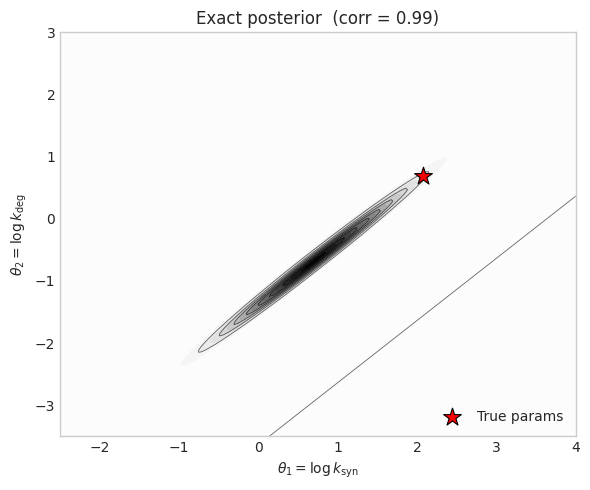

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(T1, T2, post, levels=20, cmap='Greys')
ax.contour(T1, T2, post, levels=8, colors='black', linewidths=0.6, alpha=0.6)
ax.scatter([theta_true[0]], [theta_true[1]], color='red', marker='*', s=180,
           edgecolor='black', linewidth=0.8, zorder=5, label='True params')
ax.set_xlabel(r'$\theta_1 = \log k_{\mathrm{syn}}$')
ax.set_ylabel(r'$\theta_2 = \log k_{\mathrm{deg}}$')
ax.set_title(f'Exact posterior  (corr = {corr_exact:.2f})')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

The posterior is a tight diagonal ridge — knowing $\theta_1 - \theta_2$ (the log steady-state level) doesn't tell us the rates individually. A Gaussian variational family that **ignores the off-diagonal correlation** will be a poor fit; one that captures it should match the ridge closely.

## Step 3: The NumPyro Model

Below is the entire generative story written in NumPyro. Each `numpyro.sample` site is a node in a probabilistic graph: latent sites contribute $\log p(\boldsymbol{\theta})$, observed sites contribute $\log p(\mathbf{y}\mid\boldsymbol{\theta})$. NumPyro accumulates both when tracing the model, which is what `Trace_ELBO` consumes inside the SVI loop.

A few NumPyro idioms worth pointing out:
- `dist.Normal(0., 1.).expand([2]).to_event(1)` — declares a single 2-dimensional latent site $\boldsymbol{\theta}$ with two independent $\mathcal{N}(0,1)$ components. `to_event(1)` tells NumPyro to treat the last axis as a single joint event rather than two independent draws, so the autoguide sees one 2-vector latent (matching the JAX notebook's `(S, 2)` shape).
- `numpyro.plate("data", N)` — declares that the observations are conditionally independent given $\boldsymbol{\theta}$, so log-probabilities sum over the plate. With $\lambda$ a scalar and `y_obs` shape `(N,)`, broadcasting under the plate gives exactly $\sum_n \log p(y_n \mid \lambda)$.

In [5]:
def model(y_obs):
    theta = numpyro.sample(
        "theta",
        dist.Normal(jnp.zeros(2), jnp.ones(2)).to_event(1),
    )
    lam = jnp.exp(theta[0] - theta[1])
    with numpyro.plate("data", y_obs.shape[0]):
        numpyro.sample("y", dist.Poisson(lam), obs=y_obs)

## Step 4: A Generic SVI Trainer

All three families share the same training loop:
1. Build the guide (one of the autoguides).
2. Wire model + guide + optimizer + ELBO into `SVI`.
3. JIT `svi.update` (NumPyro does this internally on first call).
4. Step the optimizer; log the ELBO every `log_every` iterations.

`Trace_ELBO(num_particles=64)` draws 64 reparameterized samples per gradient step, matching the JAX trainer's `num_samples=64`. `svi.update` returns the **negative** ELBO (a loss to minimize), so we negate when reporting.

In [6]:
def train_svi(guide, key, num_steps=2000, num_samples=64, lr=1e-2, log_every=200):
    """Run SVI for num_steps. Returns (fitted params dict, ELBO trace as list)."""
    optimizer = numpyro.optim.Adam(step_size=lr)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO(num_particles=num_samples))
    state = svi.init(key, y_j)

    losses = []
    for s in range(num_steps):
        state, loss = svi.update(state, y_j)
        losses.append(float(loss))
        if (s + 1) % log_every == 0:
            print(f"  step {s+1:>4d}  ELBO = {-float(loss):.3f}")

    params = svi.get_params(state)
    return params, [-l for l in losses]

## Step 5: Diagonal Gaussian (Mean Field) — `AutoNormal`

$$\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad \mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}$$

`AutoNormal` registers two NumPyro params per latent site: `{site}_auto_loc` ($\boldsymbol{\mu}$) and `{site}_auto_scale` (positive $\boldsymbol{\sigma}$, stored unconstrained and transformed). For our single latent site `"theta"` the keys are `theta_auto_loc` and `theta_auto_scale`. The guide samples each component independently — there is no off-diagonal entry to learn, the textbook mean-field family.

In [7]:
print("Training AutoNormal (mean-field) ...")
key, sub = jr.split(key)
guide_diag = AutoNormal(model)
params_diag, trace_diag = train_svi(guide_diag, sub, num_steps=2000)

mu_diag = np.asarray(params_diag['theta_auto_loc'])
sigma_diag = np.asarray(params_diag['theta_auto_scale'])
Sigma_diag = np.diag(sigma_diag ** 2)
print(f"\nFitted q: mu = {mu_diag},  sigma = {sigma_diag}")
print(f"Covariance:\n{Sigma_diag}")

Training AutoNormal (mean-field) ...


  step  200  ELBO = -72.183


  step  400  ELBO = -71.928


  step  600  ELBO = -71.694


  step  800  ELBO = -71.360


...

  step 1200  ELBO = -71.240


  step 1400  ELBO = -71.061


  step 1600  ELBO = -71.014


  step 1800  ELBO = -70.615


  step 2000  ELBO = -70.838

Fitted q: mu = [ 0.9904939  -0.39781883],  sigma = [0.08982077 0.09087621]
Covariance:
[[0.00806777 0.        ]
 [0.         0.00825849]]


## Step 6: Full Covariance Gaussian — `AutoMultivariateNormal`

$$\mathbf{z} = \boldsymbol{\mu} + \mathbf{L}\boldsymbol{\epsilon}, \qquad \boldsymbol{\Sigma} = \mathbf{L}\mathbf{L}^\top.$$

`AutoMultivariateNormal` registers `auto_loc` ($\boldsymbol{\mu}$) and `auto_scale_tril` (the lower-triangular Cholesky factor $\mathbf{L}$, constrained to have positive diagonal). Sampling and log-density both go through `dist.MultivariateNormal(loc=mu, scale_tril=L)`, which uses $\mathbf{L}$ directly — no re-factorization of $\boldsymbol{\Sigma}$.

In [8]:
print("Training AutoMultivariateNormal (full covariance) ...")
key, sub = jr.split(key)
guide_full = AutoMultivariateNormal(model)
params_full, trace_full = train_svi(guide_full, sub, num_steps=2000)

mu_full = np.asarray(params_full['auto_loc'])
L_full = np.asarray(params_full['auto_scale_tril'])
Sigma_full = L_full @ L_full.T
corr_full = Sigma_full[0, 1] / np.sqrt(Sigma_full[0, 0] * Sigma_full[1, 1])
print(f"\nFitted q: mu = {mu_full}")
print(f"Covariance:\n{Sigma_full}")
print(f"Implied correlation: {corr_full:.3f}  (exact: {corr_exact:.3f})")

Training AutoMultivariateNormal (full covariance) ...


  step  200  ELBO = -70.072


  step  400  ELBO = -69.509


  step  600  ELBO = -69.307


  step  800  ELBO = -68.916


...

  step 1400  ELBO = -68.755


  step 1600  ELBO = -68.651


  step 1800  ELBO = -68.785


  step 2000  ELBO = -68.659



Fitted q: mu = [ 0.66155726 -0.71552366]
Covariance:
[[0.40327033 0.39408743]
 [0.39408743 0.39484042]]
Implied correlation: 0.988  (exact: 0.992)


## Step 7: Low-Rank + Diagonal Gaussian — `AutoLowRankMultivariateNormal`

For high-dimensional latent spaces, full covariance has $O(d^2)$ parameters. A cheap middle ground is the rank-$r$ plus diagonal decomposition
$$\boldsymbol{\Sigma} = \mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2),$$
with only $(r{+}2)\,d$ parameters total. For our 2D problem with the default $r = \lfloor\sqrt{d}\rfloor = 1$ this is also a full-covariance family — we use it to verify it recovers the same posterior.

`AutoLowRankMultivariateNormal` registers `auto_loc`, `auto_cov_factor` ($\tilde{\mathbf{b}} \in \mathbb{R}^{d \times r}$), and `auto_scale` (positive $\mathbf{c} \in \mathbb{R}^d_+$). Internally NumPyro builds the covariance as $\boldsymbol{\Sigma} = \mathrm{diag}(\mathbf{c})\,\tilde{\mathbf{b}}\tilde{\mathbf{b}}^\top\mathrm{diag}(\mathbf{c}) + \mathrm{diag}(\mathbf{c}^2)$ — equivalent to the book's $\mathbf{b}\mathbf{b}^\top + \mathrm{diag}(\mathbf{c}^2)$ with $\mathbf{b} = \mathrm{diag}(\mathbf{c})\,\tilde{\mathbf{b}}$ — and then uses `dist.LowRankMultivariateNormal`, which evaluates the log-density via the **Woodbury identity** and **matrix-determinant lemma** so the cost is $O(d r^2)$ instead of $O(d^3)$.

In [9]:
print("Training AutoLowRankMultivariateNormal (rank=1 + diagonal) ...")
key, sub = jr.split(key)
guide_lr = AutoLowRankMultivariateNormal(model, rank=1)
params_lr, trace_lr = train_svi(guide_lr, sub, num_steps=2000)

mu_lr = np.asarray(params_lr['auto_loc'])
W_raw = np.asarray(params_lr['auto_cov_factor'])         # raw cov_factor, (d, r)
c_lr  = np.asarray(params_lr['auto_scale'])              # diagonal sqrt c, (d,)
W_lr  = W_raw * c_lr[:, None]                            # NumPyro's effective factor: diag(c) @ W_raw
Sigma_lr = W_lr @ W_lr.T + np.diag(c_lr ** 2)
# Sanity check vs the guide's own posterior distribution:
Sigma_lr_guide = np.asarray(guide_lr.get_posterior(params_lr).covariance_matrix)
assert np.allclose(Sigma_lr, Sigma_lr_guide, atol=1e-5), (Sigma_lr, Sigma_lr_guide)
corr_lr = Sigma_lr[0, 1] / np.sqrt(Sigma_lr[0, 0] * Sigma_lr[1, 1])
print(f"\nFitted q: mu = {mu_lr}")
print(f"Covariance:\n{Sigma_lr}")
print(f"Implied correlation: {corr_lr:.3f}  (exact: {corr_exact:.3f})")

Training AutoLowRankMultivariateNormal (rank=1 + diagonal) ...


  step  200  ELBO = -70.676


  step  400  ELBO = -69.706


  step  600  ELBO = -69.376


  step  800  ELBO = -69.204


...

  step 1400  ELBO = -68.867


  step 1600  ELBO = -68.817


  step 1800  ELBO = -68.769


  step 2000  ELBO = -68.819



Fitted q: mu = [ 0.68167156 -0.6981899 ]
Covariance:
[[0.28469497 0.28322738]
 [0.28322738 0.29402974]]
Implied correlation: 0.979  (exact: 0.992)


## Step 8: Side-by-Side Comparison (mirrors Figure 10.2)

We overlay the three Gaussian approximations on top of the exact posterior. The mean-field axis-aligned ellipse will be **clearly over-confident** in the direction transverse to the ridge — a textbook example of why the mode-seeking KL$(q \| p)$ makes diagonal Gaussians collapse onto a single dimension of the posterior.

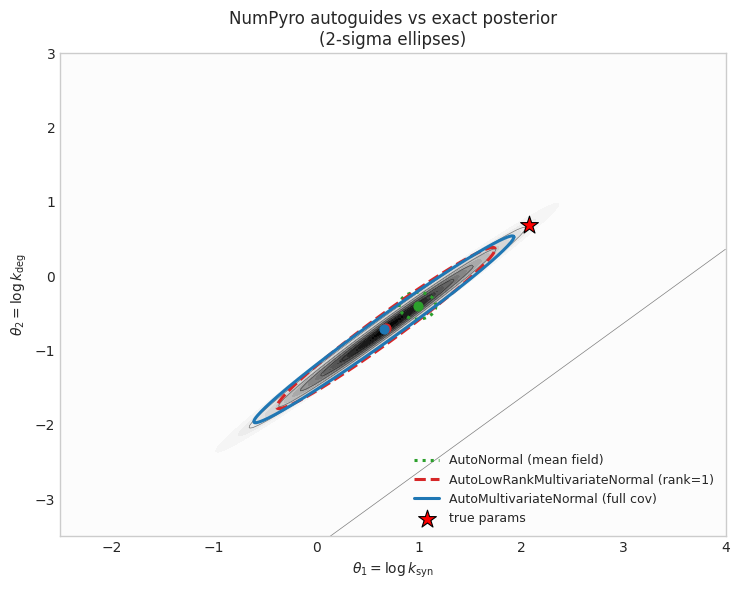

In [10]:
def gaussian_ellipse(mu, Sigma, n_std=2.0, n_pts=200):
    """Return points on the n_std-ellipse of N(mu, Sigma)."""
    L = np.linalg.cholesky(Sigma + 1e-8 * np.eye(len(mu)))
    t = np.linspace(0, 2*np.pi, n_pts)
    circle = n_std * np.vstack([np.cos(t), np.sin(t)])
    pts = mu[:, None] + L @ circle
    return pts[0], pts[1]

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.contourf(T1, T2, post, levels=20, cmap='Greys')
ax.contour(T1, T2, post, levels=6, colors='black', linewidths=0.5, alpha=0.5)

for q_mu, q_Sigma, color, style, label in [
    (mu_diag, Sigma_diag, '#2ca02c', ':',  'AutoNormal (mean field)'),
    (mu_lr,   Sigma_lr,   '#d62728', '--', 'AutoLowRankMultivariateNormal (rank=1)'),
    (mu_full, Sigma_full, '#1f77b4', '-',  'AutoMultivariateNormal (full cov)'),
]:
    xs, ys = gaussian_ellipse(q_mu, q_Sigma, n_std=2.0)
    ax.plot(xs, ys, color=color, linestyle=style, linewidth=2.2, label=label)
    ax.scatter([q_mu[0]], [q_mu[1]], color=color, s=40, zorder=4)

ax.scatter([theta_true[0]], [theta_true[1]], color='red', marker='*',
           s=180, edgecolor='black', linewidth=0.8, zorder=5, label='true params')
ax.set_xlabel(r'$\theta_1 = \log k_{\mathrm{syn}}$')
ax.set_ylabel(r'$\theta_2 = \log k_{\mathrm{deg}}$')
ax.set_title('NumPyro autoguides vs exact posterior\n(2-sigma ellipses)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Step 9: Quantitative Comparison

We compare each variational family on three criteria:
1. **Mean recovery** — distance from $\mathbb{E}_q[\boldsymbol{\theta}]$ to the exact posterior mean.
2. **Correlation recovery** — does the implied correlation match the exact $\rho \approx 1$?
3. **Final ELBO** — higher is better (closer to $\log p(\mathbf{y})$).

And we report the **marginal** posterior on the well-identified direction $\theta_1 - \theta_2$, which all three methods should get right because the data strongly constrains it.

In [11]:
# Posterior variance of the well-identified contrast theta1 - theta2 under each q.
def contrast_stats(mu, Sigma):
    v = np.array([1.0, -1.0])
    return v @ mu, np.sqrt(v @ Sigma @ v)

rows = [
    ("exact",            np.array([mu1_exact, mu2_exact]),
        np.array([[var1_exact, cov_exact], [cov_exact, var2_exact]]),  None),
    ("AutoNormal",       mu_diag, Sigma_diag, trace_diag[-50:]),
    ("AutoLowRankMVN",   mu_lr,   Sigma_lr,   trace_lr[-50:]),
    ("AutoMultivarMVN",  mu_full, Sigma_full, trace_full[-50:]),
]

print(f"{'method':<17} | {'E[t1]':>7} {'E[t2]':>7} | {'sd(t1)':>7} {'sd(t2)':>7} | {'corr':>6} | {'E[t1-t2]':>9} {'sd(t1-t2)':>10} | {'ELBO':>8}")
print("-" * 105)
for name, mu, Sigma, trace in rows:
    c, sdc = contrast_stats(mu, Sigma)
    corr = Sigma[0, 1] / np.sqrt(Sigma[0, 0] * Sigma[1, 1])
    elbo = f"{np.mean(trace):.3f}" if trace is not None else "-"
    print(f"{name:<17} | {mu[0]:>7.3f} {mu[1]:>7.3f} | "
          f"{np.sqrt(Sigma[0,0]):>7.3f} {np.sqrt(Sigma[1,1]):>7.3f} | "
          f"{corr:>6.3f} | {c:>9.3f} {sdc:>10.4f} | {elbo:>8}")

method            |   E[t1]   E[t2] |  sd(t1)  sd(t2) |   corr |  E[t1-t2]  sd(t1-t2) |     ELBO
---------------------------------------------------------------------------------------------------------
exact             |   0.692  -0.692 |   0.708   0.708 |  0.992 |     1.385     0.0912 |        -
AutoNormal        |   0.990  -0.398 |   0.090   0.091 |  0.000 |     1.388     0.1278 |  -70.835
AutoLowRankMVN    |   0.682  -0.698 |   0.534   0.542 |  0.979 |     1.380     0.1108 |  -68.791
AutoMultivarMVN   |   0.662  -0.716 |   0.635   0.628 |  0.988 |     1.377     0.0997 |  -68.694


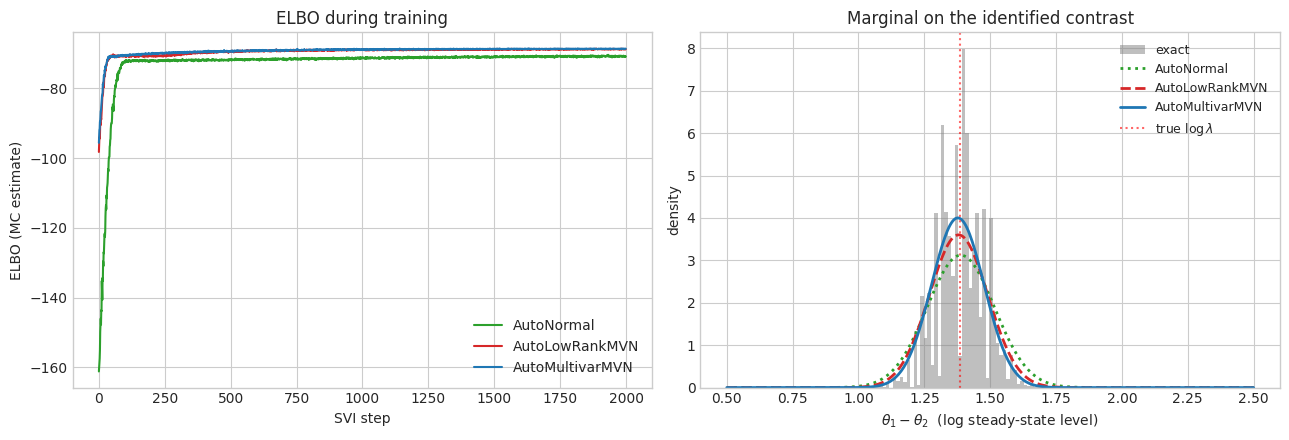

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: ELBO traces
ax = axes[0]
ax.plot(trace_diag, label='AutoNormal',      color='#2ca02c')
ax.plot(trace_lr,   label='AutoLowRankMVN',  color='#d62728')
ax.plot(trace_full, label='AutoMultivarMVN', color='#1f77b4')
ax.set_xlabel('SVI step')
ax.set_ylabel('ELBO (MC estimate)')
ax.set_title('ELBO during training')
ax.legend()

# Right: Marginal on theta1 - theta2 (the well-identified contrast)
ax = axes[1]
diff_grid = np.linspace(0.5, 2.5, 400)
samples_idx = np.random.choice(post.size, size=80000, p=(post/post.sum()).ravel())
ii, jj = np.unravel_index(samples_idx, post.shape)
diff_samples_exact = T1[ii, jj] - T2[ii, jj]
ax.hist(diff_samples_exact, bins=60, density=True, color='gray', alpha=0.5,
        label='exact')

for q_mu, q_Sigma, color, style, label in [
    (mu_diag, Sigma_diag, '#2ca02c', ':',  'AutoNormal'),
    (mu_lr,   Sigma_lr,   '#d62728', '--', 'AutoLowRankMVN'),
    (mu_full, Sigma_full, '#1f77b4', '-',  'AutoMultivarMVN'),
]:
    m, s = contrast_stats(q_mu, q_Sigma)
    pdf = np.exp(-0.5 * ((diff_grid - m) / s) ** 2) / (s * np.sqrt(2*np.pi))
    ax.plot(diff_grid, pdf, color=color, linestyle=style, linewidth=2, label=label)

ax.axvline(np.log(lambda_true), color='red', linestyle=':', alpha=0.6,
           label=r'true $\log \lambda$')
ax.set_xlabel(r'$\theta_1 - \theta_2$  (log steady-state level)')
ax.set_ylabel('density')
ax.set_title('Marginal on the identified contrast')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Step 10: Why Mean-Field is Over-Confident

$D_{\mathrm{KL}}(q \| p)$ is **mode-seeking**: it penalizes putting mass where $p$ is zero, so it shrinks $q$ to fit *inside* the high-probability region of $p$. For a diagonal-Gaussian $q$ approximating a tilted posterior, the only way to fit *inside* the diagonal ridge is to **shrink to a point near its center** — losing variance in both directions.

The full-covariance and low-rank+diag families instead align their major axis with the ridge, recovering the right variance in the well-identified direction (small variance along $\theta_1 - \theta_2$) and in the unidentified direction (large variance along $\theta_1 + \theta_2$, set by the prior).

This is exactly the lesson of **Figure 10.2** in PML-2: in high-dim posteriors with structure, even cheap rank-1 corrections are worth a lot.

## Summary

### What we built
We posed a Bayesian inference problem with a structured 2D posterior — joint inference of mRNA synthesis and degradation rates from steady-state RNA-seq counts — and fit it three ways using **NumPyro's autoguides**, which implement reparameterized variational inference end-to-end:

| Family | Parameters | Captures correlation? | NumPyro guide |
|---|---|---|---|
| Diagonal (mean field) | $2d$ | No | `AutoNormal` |
| Full (Cholesky) | $d(d+3)/2$ | Yes | `AutoMultivariateNormal` |
| Low-rank + diag | $(r{+}2)d$ | Yes, the dominant $r$ directions | `AutoLowRankMultivariateNormal` |

### Key takeaways from PML-2 §10.2
1. **Reparameterization** (Eq. 10.36–10.40) is the gradient estimator behind every autoguide here. NumPyro applies it transparently for any distribution with `has_rsample = True`.
2. The **diagonal Gaussian** is the easiest reparameterization (Eq. 10.44) but cannot capture posterior correlation — a well-known mode-seeking failure of $D_{\mathrm{KL}}(q \| p)$.
3. The **full Cholesky** parameterization captures all correlations but costs $O(d^2)$ parameters.
4. The **low-rank + diagonal** factorization (VAFC, Eq. 10.57) costs only $O(d r)$ extra parameters yet recovers the dominant correlation direction.
5. The same `SVI` machinery composes with **minibatching** (Section 10.1.4) via `numpyro.plate(..., subsample_size=...)` and with **amortization** (Section 10.1.5) by replacing the autoguide with a custom guide that calls a neural network.

### NumPyro-specific notes vs. the JAX sibling notebook
- **No hand-derived log-densities.** The model is declared with `numpyro.sample` and `numpyro.plate`; `Trace_ELBO` reconstructs $\log p(\mathbf{x}, \mathbf{z}) - \log q_{\boldsymbol{\psi}}(\mathbf{z})$ from the traces. The JAX notebook's `log_joint_jax` and per-family `sample(...) -> (z, log_q)` functions disappear into one-line autoguide instantiations.
- **Param dict, not pytree.** Variational parameters live in a flat Python dict. `AutoNormal` registers one (`loc`, `scale`) pair per latent site (here `theta_auto_loc`, `theta_auto_scale`); `AutoMultivariateNormal` packs all latents into a single flat vector with `auto_loc` and `auto_scale_tril`; `AutoLowRankMultivariateNormal` uses `auto_loc`, `auto_cov_factor`, and `auto_scale` — and applies the internal whitening $\tilde{\mathbf{b}} \to \mathrm{diag}(\mathbf{c})\,\tilde{\mathbf{b}}$ before passing to `LowRankMultivariateNormal`, so reconstructing $\boldsymbol{\Sigma}$ from the raw params requires the same scaling.
- **Mean-field is allowed to slide along the ridge.** When the variational sd collapses to ~0.09, the mean field ELBO becomes nearly flat along the well-identified contrast $\theta_1 - \theta_2 = \text{const}$. Different random seeds / optimizer noise can land the fitted $\boldsymbol{\mu}$ at different points on that ridge — the contrast value is unchanged, but the individual coordinates of $\boldsymbol{\mu}$ can drift from the exact posterior mean. The JAX sibling notebook happened to land near $(0.69, -0.69)$; NumPyro lands elsewhere on the same ridge. This is a feature of the family, not a bug.
- **`svi.update` is JIT-compiled internally.** We keep a Python loop for progress logging; switching to `svi.run(rng_key, num_steps, ...)` would run the same loop fused as `lax.scan` with no logging overhead.
- **Trace_ELBO loss is the negative ELBO.** That is why we negate `loss` when reporting and plotting.